# Analisis Sentimen Review Aplikasi DANA Menggunakan SVM dan Naive Bayes

Notebook ini disusun mengikuti tahapan CRISP-DM: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment.


Pada tahap awal, library yang dibutuhkan akan diinstall terlebih dahulu. Library `kagglehub` digunakan untuk mengambil dataset dari Kaggle, `Sastrawi` digunakan untuk stopword Bahasa Indonesia, dan `wordcloud` digunakan untuk membuat visualisasi kata yang sering muncul.

In [1]:
!pip install kagglehub Sastrawi wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.9 MB/s eta 0:00:00


Pada bagian ini, seluruh library yang dibutuhkan dalam proyek dipanggil. Library tersebut digunakan untuk mengolah data, membersihkan teks, membuat visualisasi, membangun model machine learning, mengevaluasi model, dan menyimpan model.

In [2]:
import kagglehub
import os
import glob
import re
import string
import joblib
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

 ## Business Understanding

Proyek ini bertujuan untuk menganalisis sentimen review pengguna aplikasi DANA berdasarkan data ulasan dari Google Play Store. Permasalahan yang ingin diselesaikan adalah bagaimana sistem dapat mengklasifikasikan review pengguna ke dalam kategori sentimen tertentu, misalnya positif, negatif, atau netral.

Pada proyek ini digunakan dua metode machine learning, yaitu **Support Vector Machine (SVM)** dan **Naive Bayes**. SVM digunakan karena termasuk metode yang sudah dipelajari, sedangkan Naive Bayes digunakan sebagai metode tambahan karena sering digunakan dalam klasifikasi teks.

Dataset yang digunakan adalah **DANA Sentiment Analysis from Playstore Indonesia** dari Kaggle. Dataset ini diunduh langsung menggunakan `kagglehub` agar proses pengambilan data lebih praktis dan tidak perlu upload file secara manual.

In [3]:
path = kagglehub.dataset_download("alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia")

print("Path to dataset files:", path)

100%|██████████| 1.68M/1.68M [00:00<00:00, 79.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia/versions/1


Setelah dataset berhasil diunduh, isi folder dataset dicek untuk mengetahui file apa saja yang tersedia di dalam folder hasil download.

In [4]:
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/datasets/alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia/versions/1/review_dana_labelled.csv


File CSV dari dataset dicari secara otomatis, kemudian dibaca menggunakan pandas agar data dapat diproses dalam bentuk dataframe.

In [5]:
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

print("File CSV ditemukan:")
for file in csv_files:
    print(file)

if len(csv_files) == 0:
    raise FileNotFoundError("File CSV tidak ditemukan. Cek kembali folder dataset.")

file_path = csv_files[0]

try:
    df = pd.read_csv(file_path)
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding="latin-1")

df.head()

File CSV ditemukan:
/root/.cache/kagglehub/datasets/alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia/versions/1/review_dana_labelled.csv


,userName,score,at,content,sentimen
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE


## Data Understanding

Tahap Data Understanding dilakukan untuk memahami kondisi awal dataset. Pada tahap ini dilihat jumlah baris dan kolom dataset.

In [6]:
print("Jumlah baris dan kolom:", df.shape)

Jumlah baris dan kolom: (50000, 5)


Informasi dataset ditampilkan untuk mengetahui nama kolom, tipe data, dan jumlah data yang tidak kosong pada setiap kolom.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  50000 non-null  object
 1   score     50000 non-null  int64 
 2   at        50000 non-null  object
 3   content   50000 non-null  object
 4   sentimen  50000 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.9+ MB


Nama-nama kolom ditampilkan untuk mengetahui atribut apa saja yang tersedia dalam dataset.

In [8]:
df.columns

Index(['userName', 'score', 'at', 'content', 'sentimen'], dtype='object')

Lima data pertama ditampilkan untuk melihat gambaran awal isi dataset.

In [9]:
df.head()

,userName,score,at,content,sentimen
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE


Missing value dicek untuk mengetahui kolom mana saja yang memiliki data kosong. Pemeriksaan ini penting sebelum data masuk ke tahap preprocessing.

In [10]:
df.isnull().sum()

,0
userName,0
score,0
at,0
content,0
sentimen,0


Data duplikat dicek untuk mengetahui apakah terdapat baris data yang sama dalam dataset.

In [11]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


Visualisasi missing value dibuat agar jumlah data kosong pada setiap kolom lebih mudah dipahami.

In [12]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(missing_values.index, missing_values.values)
    plt.title("Jumlah Missing Value pada Setiap Kolom")
    plt.xlabel("Nama Kolom")
    plt.ylabel("Jumlah Missing Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing value pada dataset.")

Tidak ada missing value pada dataset.



Pada bagian ini, nama kolom dirapikan agar lebih konsisten dan mudah dipanggil dalam kode. Semua nama kolom dibuat menjadi huruf kecil dan spasi diganti dengan garis bawah.

In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df.columns

Index(['username', 'score', 'at', 'content', 'sentimen'], dtype='object')

Kolom teks review dan kolom label sentimen dicari secara otomatis. Jika kolom sentimen belum tersedia, label sentimen akan dibuat dari kolom skor/rating aplikasi.

In [14]:
def pilih_kolom(kandidat):
    for kolom in kandidat:
        if kolom in df.columns:
            return kolom
    return None

text_col = pilih_kolom([
    "content", "review", "ulasan", "komentar", "text", "review_text"
])

label_col = pilih_kolom([
    "sentiment", "sentimen", "label", "sentiment_label", "kategori_sentimen"
])

score_col = pilih_kolom([
    "score", "rating", "stars", "bintang"
])

print("Kolom teks:", text_col)
print("Kolom label:", label_col)
print("Kolom score:", score_col)

if text_col is None:
    raise ValueError("Kolom teks review tidak ditemukan. Cek kembali nama kolom dataset.")

Kolom teks: content
Kolom label: sentimen
Kolom score: score


Jika dataset belum memiliki label sentimen, label dibuat berdasarkan skor aplikasi. Review dengan skor 4 sampai 5 dianggap positif, skor 3 dianggap netral, sedangkan skor 1 sampai 2 dianggap negatif.

In [15]:
if label_col is None:
    if score_col is not None:
        def buat_sentimen(score):
            try:
                score = float(score)
                if score >= 4:
                    return "positif"
                elif score == 3:
                    return "netral"
                else:
                    return "negatif"
            except:
                return np.nan

        df["sentimen_baru"] = df[score_col].apply(buat_sentimen)
        label_col = "sentimen_baru"
        print("Label sentimen dibuat dari kolom score.")
    else:
        raise ValueError("Kolom sentimen dan kolom score tidak ditemukan.")
else:
    print("Dataset sudah memiliki kolom label sentimen.")

Dataset sudah memiliki kolom label sentimen.


Visualisasi distribusi skor dibuat jika kolom skor tersedia. Visualisasi ini membantu melihat kecenderungan penilaian pengguna terhadap aplikasi DANA.

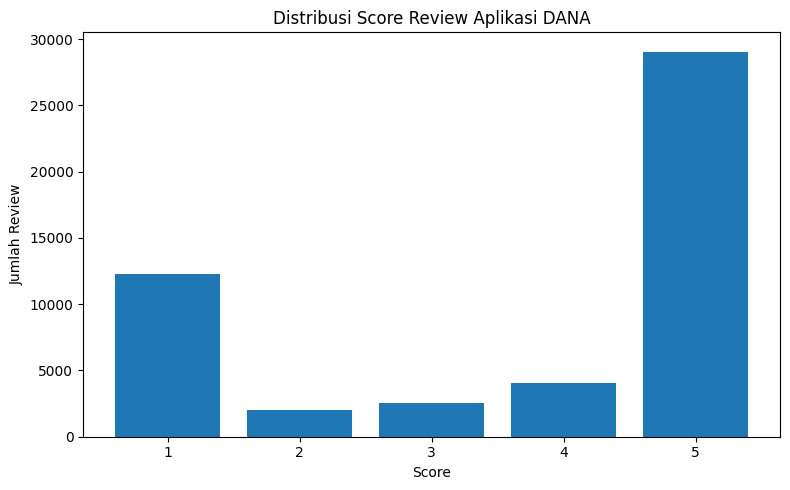

In [16]:
if score_col is not None:
    score_data = pd.to_numeric(df[score_col], errors="coerce").dropna()

    if len(score_data) > 0:
        score_counts = score_data.value_counts().sort_index()

        plt.figure(figsize=(8, 5))
        plt.bar(score_counts.index.astype(str), score_counts.values)
        plt.title("Distribusi Score Review Aplikasi DANA")
        plt.xlabel("Score")
        plt.ylabel("Jumlah Review")
        plt.tight_layout()
        plt.show()
    else:
        print("Kolom score tersedia, tetapi nilainya tidak dapat dibaca sebagai angka.")
else:
    print("Kolom score tidak tersedia.")

Visualisasi distribusi sentimen dibuat untuk melihat jumlah data pada setiap kelas sentimen. Tahap ini penting untuk mengetahui apakah data seimbang atau tidak.

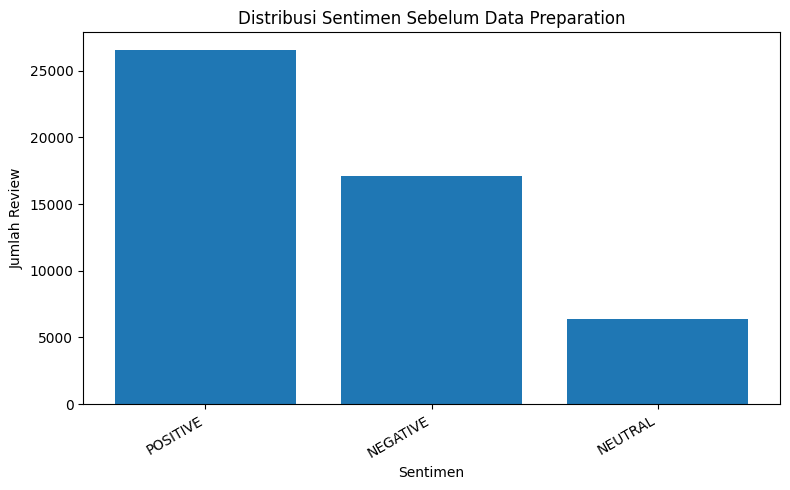

,count
sentimen,
POSITIVE,26555
NEGATIVE,17073
NEUTRAL,6372


In [17]:
sentimen_counts_awal = df[label_col].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(sentimen_counts_awal.index.astype(str), sentimen_counts_awal.values)
plt.title("Distribusi Sentimen Sebelum Data Preparation")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

sentimen_counts_awal

Pada tahap Data Preparation, hanya kolom review dan sentimen yang digunakan. Data kosong dan data duplikat dihapus agar proses pelatihan model lebih bersih.

In [18]:
data = df[[text_col, label_col]].copy()
data.columns = ["review", "sentimen"]

data = data.dropna(subset=["review", "sentimen"])
data = data.drop_duplicates(subset=["review"]).reset_index(drop=True)

print("Ukuran data setelah memilih kolom, menghapus missing value, dan menghapus duplikat:", data.shape)
data.head()

Ukuran data setelah memilih kolom, menghapus missing value, dan menghapus duplikat: (31701, 2)


,review,sentimen
0,Bagus,POSITIVE
1,Dana mmg keren mantap.,POSITIVE
2,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE
3,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE
4,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE


Label sentimen dirapikan agar penulisannya konsisten. Misalnya label positif, negative, atau Positive akan disesuaikan menjadi format yang seragam.

In [19]:
def normalisasi_label(label):
    label = str(label).lower().strip()

    if label in ["positive", "positif", "pos", "1"]:
        return "positif"
    elif label in ["negative", "negatif", "neg", "0"]:
        return "negatif"
    elif label in ["neutral", "netral", "neu", "2"]:
        return "netral"
    else:
        return label

data["sentimen"] = data["sentimen"].apply(normalisasi_label)

print("Label sentimen setelah dinormalisasi:")
print(data["sentimen"].value_counts())

Label sentimen setelah dinormalisasi:
sentimen
negatif    14030
positif    11570
netral      6101
Name: count, dtype: int64


Pada bagian ini, teks review dibersihkan. Proses cleaning meliputi mengubah huruf menjadi kecil, menghapus URL, angka, tanda baca, simbol, spasi berlebih, dan stopword Bahasa Indonesia.

In [20]:
factory = StopWordRemoverFactory()
stopwords_indonesia = set(factory.get_stop_words())

# Tambahan stopword yang sering muncul pada review aplikasi
stopwords_tambahan = {
    "dana", "aplikasi", "apk", "app", "yg", "ga", "gak", "nggak", "tdk",
    "nya", "aja", "sih", "dong", "banget", "nih", "deh", "min"
}

stopwords_indonesia = stopwords_indonesia.union(stopwords_tambahan)

def clean_text(text):
    text = str(text).lower()

    # Menghapus URL
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Menghapus mention dan hashtag
    text = re.sub(r"@\w+|#\w+", " ", text)

    # Menghapus angka
    text = re.sub(r"\d+", " ", text)

    # Menghapus tanda baca
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Menghapus karakter selain huruf dan spasi
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Menghapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    # Menghapus stopword
    words = text.split()
    words = [word for word in words if word not in stopwords_indonesia and len(word) > 2]

    return " ".join(words)

data["clean_review"] = data["review"].apply(clean_text)

data[["review", "clean_review", "sentimen"]].head()

,review,clean_review,sentimen
0,Bagus,bagus,positif
1,Dana mmg keren mantap.,mmg keren mantap,positif
2,Saya ngajuin upgrade dana premium krna ktp say...,ngajuin upgrade premium krna ktp buram jdi ver...,negatif
3,Kocak mana diskon nya ml malah eror segala kag...,kocak mana diskon malah eror segala kaga ikhla...,negatif
4,Saldo hilang karena no lama Hilang ganti no sa...,saldo hilang lama hilang ganti saldonya sama s...,negatif


Data dengan hasil cleaning kosong dihapus karena tidak memberikan informasi untuk model. Setelah itu distribusi sentimen dicek kembali.

In [21]:
data = data[data["clean_review"].str.strip() != ""].reset_index(drop=True)

print("Ukuran data setelah cleaning:", data.shape)
print(data["sentimen"].value_counts())

Ukuran data setelah cleaning: (31330, 3)
sentimen
negatif    13971
positif    11467
netral      5892
Name: count, dtype: int64


Visualisasi distribusi sentimen setelah data preparation dibuat untuk memastikan jumlah data pada setiap kelas sentimen setelah pembersihan teks.

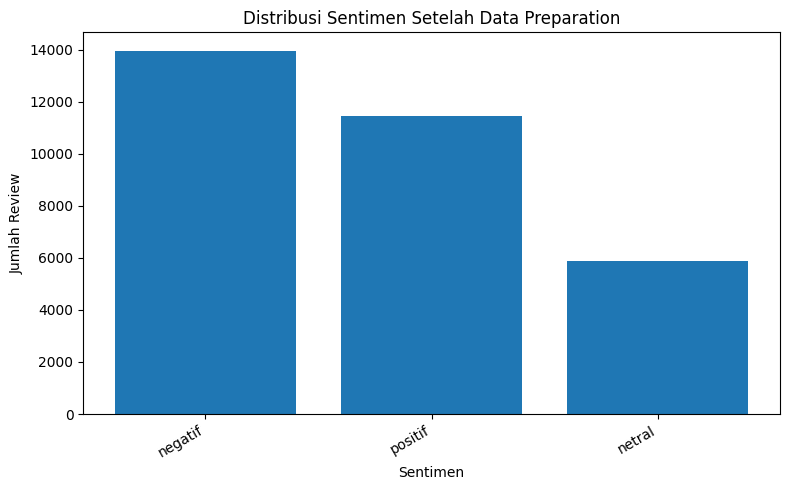

In [22]:
sentimen_counts = data["sentimen"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(sentimen_counts.index.astype(str), sentimen_counts.values)
plt.title("Distribusi Sentimen Setelah Data Preparation")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Panjang review dihitung berdasarkan jumlah kata setelah preprocessing. Visualisasi ini digunakan untuk melihat apakah sebagian besar review berbentuk pendek atau panjang.

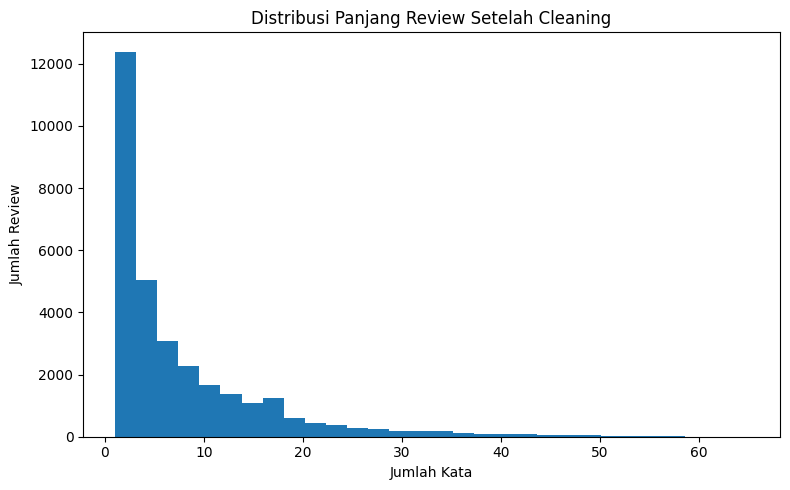

,clean_review,jumlah_kata
0,bagus,1
1,mmg keren mantap,3
2,ngajuin upgrade premium krna ktp buram jdi ver...,26
3,kocak mana diskon malah eror segala kaga ikhla...,10
4,saldo hilang lama hilang ganti saldonya sama s...,14


In [23]:
data["jumlah_kata"] = data["clean_review"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 5))
plt.hist(data["jumlah_kata"], bins=30)
plt.title("Distribusi Panjang Review Setelah Cleaning")
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Review")
plt.tight_layout()
plt.show()

data[["clean_review", "jumlah_kata"]].head()

Visualisasi top 20 kata yang paling sering muncul dibuat untuk mengetahui kata-kata dominan dalam review pengguna aplikasi DANA.

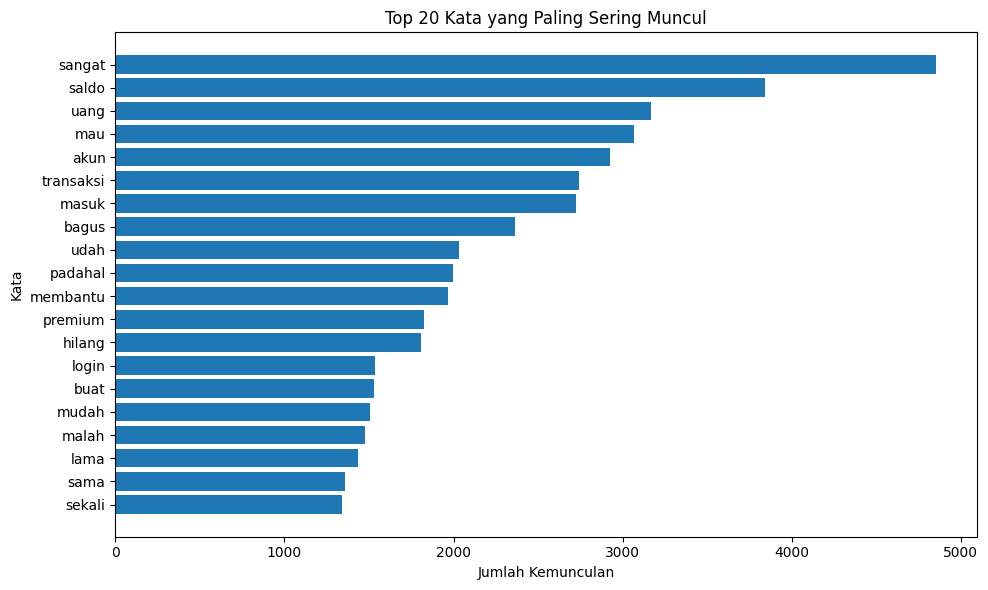

,kata,jumlah
0,sangat,4850
1,saldo,3839
2,uang,3165
3,mau,3067
4,akun,2926
5,transaksi,2740
6,masuk,2722
7,bagus,2364
8,udah,2030
9,padahal,1994


In [24]:
all_words = " ".join(data["clean_review"]).split()
word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(20), columns=["kata", "jumlah"])

plt.figure(figsize=(10, 6))
plt.barh(top_words["kata"], top_words["jumlah"])
plt.title("Top 20 Kata yang Paling Sering Muncul")
plt.xlabel("Jumlah Kemunculan")
plt.ylabel("Kata")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_words

WordCloud dibuat untuk menampilkan kata-kata yang sering muncul secara visual. Semakin besar ukuran kata, semakin sering kata tersebut muncul dalam review.

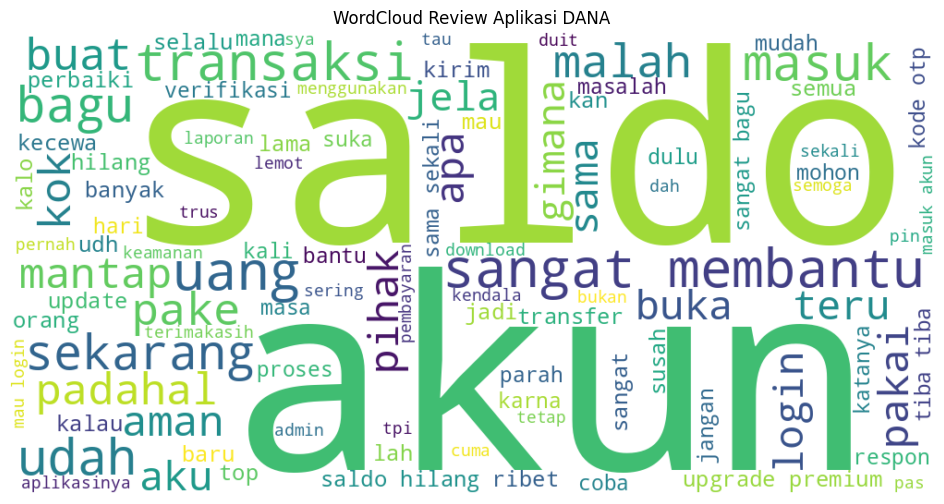

In [25]:
text_wordcloud = " ".join(data["clean_review"])

if len(text_wordcloud.strip()) > 0:
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text_wordcloud)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud Review Aplikasi DANA")
    plt.show()
else:
    print("Teks kosong, WordCloud tidak dapat dibuat.")

Data dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji performa model pada data yang belum pernah dilihat sebelumnya.

In [26]:
X = data["clean_review"]
y = data["sentimen"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 25064
Jumlah data testing: 6266


## Modeling

Pada tahap Modeling, dibuat model pertama yaitu **Support Vector Machine (SVM)**. Model ini menggunakan TF-IDF untuk mengubah teks menjadi angka, kemudian LinearSVC digunakan untuk melakukan klasifikasi sentimen.

In [27]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("classifier", LinearSVC())
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Model SVM berhasil dilatih.")

Model SVM berhasil dilatih.


Model kedua yang digunakan adalah **Naive Bayes**. Model ini juga menggunakan TF-IDF sebagai representasi teks, kemudian Multinomial Naive Bayes digunakan untuk klasifikasi sentimen.

In [28]:
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("classifier", MultinomialNB())
])

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Model Naive Bayes berhasil dilatih.")

Model Naive Bayes berhasil dilatih.


## Evaluation

Pada tahap Evaluation, performa model SVM dan Naive Bayes dibandingkan menggunakan accuracy, precision, recall, dan f1-score.

In [29]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(
    y_test, y_pred_svm, average="weighted", zero_division=0
)

precision_nb, recall_nb, f1_nb, _ = precision_recall_fscore_support(
    y_test, y_pred_nb, average="weighted", zero_division=0
)

hasil_evaluasi = pd.DataFrame({
    "Model": ["SVM", "Naive Bayes"],
    "Accuracy": [accuracy_svm, accuracy_nb],
    "Precision": [precision_svm, precision_nb],
    "Recall": [recall_svm, recall_nb],
    "F1-Score": [f1_svm, f1_nb]
})

hasil_evaluasi

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.775295,0.765807,0.775295,0.767569
1,Naive Bayes,0.748963,0.755694,0.748963,0.717220


Visualisasi perbandingan akurasi dibuat untuk melihat model mana yang memiliki performa lebih baik berdasarkan nilai accuracy.

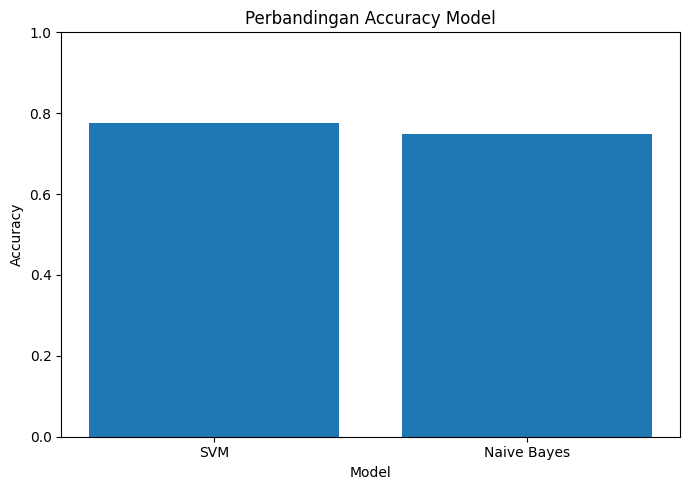

In [30]:
plt.figure(figsize=(7, 5))
plt.bar(hasil_evaluasi["Model"], hasil_evaluasi["Accuracy"])
plt.title("Perbandingan Accuracy Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Visualisasi perbandingan metrik evaluasi dibuat untuk membandingkan accuracy, precision, recall, dan f1-score dari kedua model.

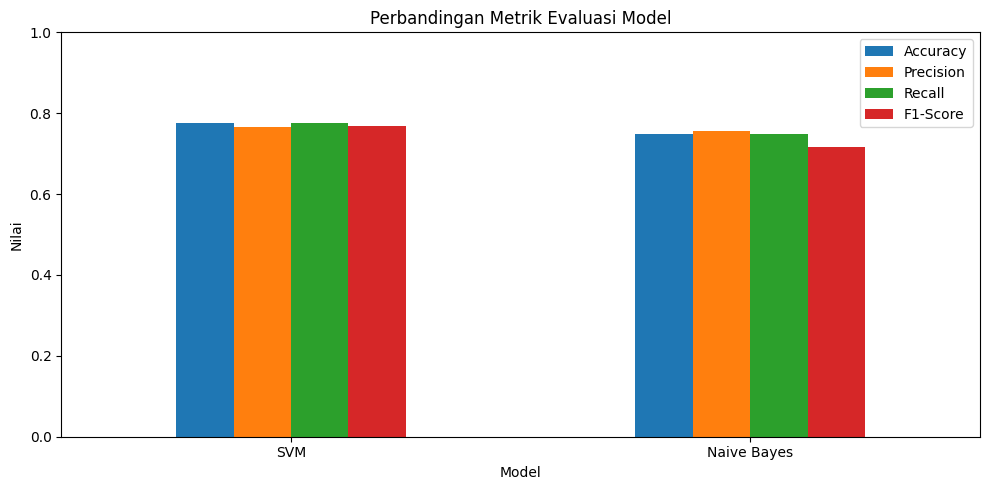

In [31]:
metric_df = hasil_evaluasi.set_index("Model")

metric_df.plot(kind="bar", figsize=(10, 5))
plt.title("Perbandingan Metrik Evaluasi Model")
plt.xlabel("Model")
plt.ylabel("Nilai")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Classification report ditampilkan untuk melihat performa model secara lebih detail pada setiap kelas sentimen.

In [32]:
print("Classification Report SVM")
print(classification_report(y_test, y_pred_svm, zero_division=0))

print("\nClassification Report Naive Bayes")
print(classification_report(y_test, y_pred_nb, zero_division=0))

Classification Report SVM
              precision    recall  f1-score   support

     negatif       0.79      0.80      0.79      2794
      netral       0.61      0.46      0.52      1178
     positif       0.82      0.91      0.86      2294

    accuracy                           0.78      6266
   macro avg       0.74      0.72      0.73      6266
weighted avg       0.77      0.78      0.77      6266


Classification Report Naive Bayes
              precision    recall  f1-score   support

     negatif       0.69      0.90      0.78      2794
      netral       0.74      0.20      0.32      1178
     positif       0.85      0.84      0.84      2294

    accuracy                           0.75      6266
   macro avg       0.76      0.65      0.65      6266
weighted avg       0.76      0.75      0.72      6266



Confusion matrix SVM dibuat untuk melihat jumlah prediksi yang benar dan salah pada setiap kelas sentimen.

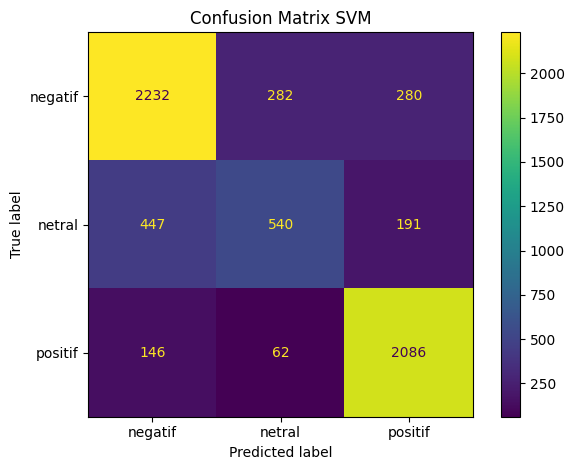

In [33]:
labels = sorted(y.unique())

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=labels
)

disp_svm.plot()
plt.title("Confusion Matrix SVM")
plt.tight_layout()
plt.show()


Confusion matrix Naive Bayes dibuat untuk melihat jumlah prediksi yang benar dan salah pada setiap kelas sentimen.

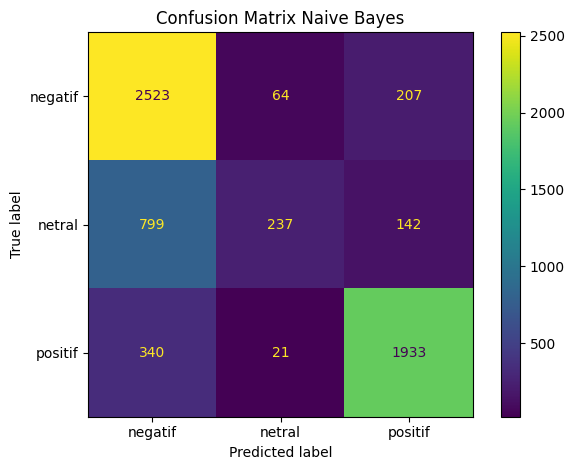

In [34]:
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=labels
)

disp_nb.plot()
plt.title("Confusion Matrix Naive Bayes")
plt.tight_layout()
plt.show()


Pada bagian ini, dibuat fungsi untuk mencoba prediksi sentimen dari teks review baru. Fungsi ini berguna untuk menunjukkan cara kerja model secara langsung saat presentasi.

In [42]:
def prediksi_sentimen(review_baru):
    review_bersih = clean_text(review_baru)

    hasil_svm = svm_model.predict([review_bersih])[0]
    hasil_nb = nb_model.predict([review_bersih])[0]

    print("Review asli:")
    print(review_baru)
    print("\nReview setelah preprocessing:")
    print(review_bersih)
    print("\nPrediksi SVM:", hasil_svm)
    print("Prediksi Naive Bayes:", hasil_nb)

Model diuji menggunakan beberapa contoh review baru. Contoh ini dapat digunakan saat presentasi untuk menunjukkan perbedaan hasil prediksi SVM dan Naive Bayes.

In [43]:
prediksi_sentimen("Aplikasi DANA sangat membantu untuk transfer dan pembayaran, prosesnya cepat dan mudah digunakan.")

Review asli:
Aplikasi DANA sangat membantu untuk transfer dan pembayaran, prosesnya cepat dan mudah digunakan.

Review setelah preprocessing:
sangat membantu transfer pembayaran prosesnya cepat mudah digunakan

Prediksi SVM: positif
Prediksi Naive Bayes: positif


In [44]:
prediksi_sentimen("Aplikasi sering error, saldo lama masuk, dan customer service tidak membantu.")

Review asli:
Aplikasi sering error, saldo lama masuk, dan customer service tidak membantu.

Review setelah preprocessing:
sering error saldo lama masuk customer service membantu

Prediksi SVM: negatif
Prediksi Naive Bayes: negatif


In [45]:
prediksi_sentimen("Lumayan bagus, tapi kadang masih lambat saat dibuka.")

Review asli:
Lumayan bagus, tapi kadang masih lambat saat dibuka.

Review setelah preprocessing:
lumayan bagus kadang lambat dibuka

Prediksi SVM: positif
Prediksi Naive Bayes: positif


Model terbaik dipilih berdasarkan nilai accuracy. Model terbaik kemudian disimpan agar dapat digunakan kembali pada tahap deployment.

In [65]:
if accuracy_svm >= accuracy_nb:
    best_model = svm_model
    best_model_name = "SVM"
else:
    best_model = nb_model
    best_model_name = "Naive Bayes"

print("Model terbaik berdasarkan accuracy:", best_model_name)

os.makedirs("model", exist_ok=True)

joblib.dump(best_model, "model/best_model.pkl")
joblib.dump(stopwords_indonesia, "model/stopwords_indonesia.pkl")
joblib.dump(hasil_evaluasi, "model/hasil_evaluasi.pkl")

print("Model dan file pendukung berhasil disimpan ke folder model.")

Model terbaik berdasarkan accuracy: SVM
Model dan file pendukung berhasil disimpan ke folder model.


## Deployment

Pada tahap Deployment, dibuat file `app.py` untuk aplikasi sederhana menggunakan Streamlit. Aplikasi ini memungkinkan pengguna memasukkan review baru, lalu sistem menampilkan prediksi sentimen dari model terbaik.

In [66]:
%%writefile app.py
import streamlit as st
import joblib
import re
import string

model = joblib.load("model/best_model.pkl")
stopwords_indonesia = joblib.load("model/stopwords_indonesia.pkl")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [word for word in words if word not in stopwords_indonesia and len(word) > 2]

    return " ".join(words)

st.title("Analisis Sentimen Review Aplikasi DANA")
st.write("Aplikasi ini memprediksi sentimen review pengguna menggunakan model machine learning terbaik.")

review = st.text_area("Masukkan review aplikasi DANA:")

if st.button("Prediksi Sentimen"):
    if review.strip() == "":
        st.warning("Masukkan review terlebih dahulu.")
    else:
        review_bersih = clean_text(review)
        prediksi = model.predict([review_bersih])[0]

        st.subheader("Hasil Prediksi")
        st.write("Sentimen:", prediksi)

        st.subheader("Teks Setelah Preprocessing")
        st.write(review_bersih)

Overwriting app.py


File `requirements.txt` dibuat untuk mencatat library yang dibutuhkan agar aplikasi Streamlit dapat dijalankan pada perangkat lain atau platform deployment.

In [67]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib
Sastrawi
wordcloud
matplotlib

Overwriting requirements.txt


Folder model dibuat menjadi file zip agar mudah diunduh dan dimasukkan ke repository GitHub bersama file `app.py` dan `requirements.txt`.

In [68]:
!zip -r model_sentimen_dana.zip model

updating: model/ (stored 0%)
updating: model/best_model.pkl (deflated 47%)
updating: model/hasil_evaluasi.pkl (deflated 45%)
updating: model/stopwords_indonesia.pkl (deflated 49%)


File hasil proyek diunduh dari Google Colab. File ini dapat dimasukkan ke repository GitHub sesuai kebutuhan tugas.

In [63]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")
files.download("model_sentimen_dana.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 ## Kesimpulan Sementara

Notebook ini sudah mencakup seluruh tahapan CRISP-DM:

1. **Business Understanding**: menjelaskan tujuan analisis sentimen review aplikasi DANA.
2. **Data Understanding**: memahami ukuran data, kolom, missing value, duplikat, dan distribusi awal data.
3. **Data Preparation**: membersihkan data, normalisasi label, preprocessing teks, dan split data.
4. **Modeling**: membangun model SVM dan Naive Bayes.
5. **Evaluation**: membandingkan model menggunakan accuracy, precision, recall, f1-score, classification report, dan confusion matrix.
6. **Deployment**: membuat file `app.py`, `requirements.txt`, serta menyimpan model untuk aplikasi Streamlit.